Dieser Codeblock berechnet **SHAP-Werte für eine logistische Regression** über eine **Repeated Stratified Cross-Validation** und sammelt daraus eine **globale Feature-Interpretation auf Log-Odds-Ebene**:

- lädt einen Datensatz mit binärer Zielvariable,
- führt eine **5×10 Repeated Stratified Cross-Validation** durch,
- skaliert die Features pro Fold mit **StandardScaler**,
- trainiert in jedem Fold eine **logistische Regression**,
- berechnet anschließend mit **SHAP LinearExplainer** die **Feature-Beiträge in Log-Odds** für die Testdaten,
- sammelt die SHAP-Werte und Testdaten über alle Folds,
- berechnet daraus pro Feature den **mittleren signierten SHAP-Wert** und den **mittleren absoluten SHAP-Wert**,
- prüft die SHAP-Werte auf **NaN/Inf und Wertebereich**,
- und gibt schließlich **alle Features sortiert nach globaler Wichtigkeit** (`mean(|SHAP|)`) aus.

Ziel ist eine **globale Interpretierbarkeit einer logistischen Regression**, um zu sehen, welche Features die Modellvorhersage im Mittel am stärksten beeinflussen und in welche Richtung.

In [1]:

import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Injury status",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False
):
    """
    Trainiert LR mit CV, sammelt SHAP-Werte (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (robuste Wichtigkeit)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int)
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap = []
    all_X    = []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None)
        )
        lr.fit(X_train_s, y_train)

        last_model   = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # expected_value robust für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)  # shape: [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Kennzahlen für Ranking & Richtung:
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_lr(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_Maestroni_korrigiert.xlsx",
    target_column        = "Injury status",
    cv_splits            = 5,
    cv_repeats           = 10,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

# Ranking nach mean(|SHAP|)
order = np.argsort(abs_mean_shaps)[::-1]
print("\nAlle Features (sortiert nach mean(|SHAP|)):")

header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print(header)
print("-" * len(header))

for i in order:   # statt order[:20]
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")




SHAP-Wertprüfung:
→ Min: -3.6429657732445517 Max: 5.56620173460773 Mean: -0.0018576542819791944
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
INV_CMJ_uni_Av. propulsive force                                   +0.005177        0.897579
INV_CMJ_uni_Peak landing force                                     +0.006635        0.894131
INV_CMJ_uni_Peak braking velocity                                  +0.012852        0.815895
UNINV_CMJ_uni_Peak braking force                                   +0.020324        0.772783
UNINV_CMJ_uni_Peak propulsive force                                -0.003434        0.638422
LSI_ISO_Extension                                                  -0.000907        0.473321
INV_ISO_Flexion-extension torque ratio                             -0.002958        0.45443

Dieser Codeblock berechnet **SHAP-Werte für ein XGBoost-Modell** über eine **Repeated Stratified Cross-Validation** und erstellt daraus eine **globale Feature-Interpretation auf Log-Odds-Ebene**:

- lädt einen Datensatz mit binärer Zielvariable,
- führt eine **5×10 Repeated Stratified Cross-Validation** durch,
- trainiert in jedem Fold ein **XGBoost-Klassifikationsmodell**,
- nutzt optional **Klassengewichtung** über `scale_pos_weight`,
- berechnet anschließend mit **SHAP TreeExplainer** die **Feature-Beiträge in Log-Odds** für die Testdaten,
- sammelt die SHAP-Werte und Testdaten über alle Folds,
- berechnet daraus pro Feature den **mittleren signierten SHAP-Wert** und den **mittleren absoluten SHAP-Wert**,
- prüft die SHAP-Werte auf **NaN/Inf und Wertebereich**,
- und gibt schließlich **alle Features sortiert nach globaler Wichtigkeit** (`mean(|SHAP|)`) aus.

Ziel ist eine **globale Interpretierbarkeit eines XGBoost-Modells**, um zu zeigen, welche Features die Vorhersage im Mittel am stärksten beeinflussen und in welche Richtung.

In [14]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from xgboost import XGBClassifier
import shap

def collect_shap_data_xgb(
    data_path,
    target_column="Injury status",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=200,     # tree SHAP doesn't require bg, but can speed/standardize baseline
    use_class_weight=False,       # uses scale_pos_weight if True
    # XGB core params (tweak as you like)
    n_estimators=500,
    learning_rate=0.05,
    max_depth=4,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    reg_alpha=0.0,
    random_state=42,
    n_jobs=-1,
    verbose=False
):
    """
    XGBoost + CV → stack SHAP (log-odds).
    Returns:
      features, shap_stack, X_stack, last_exp_val, last_model, last_test_len,
      signed_mean_shaps, abs_mean_shaps
    """
    # 1) Data
    df = pd.read_excel(data_path)
    y  = df[target_column].astype(int).values
    X  = df.drop(columns=[target_column])
    features = X.columns.tolist()
    X = X.values  # keep as numpy for xgboost

    # 2) CV
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=random_state)
    all_shap, all_X = [], []
    last_exp_val, last_model, last_test_len = None, None, None

    rng_global = np.random.default_rng(random_state)
    if verbose:
        print("→ Start XGB + SHAP (log-odds)…")

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]

        # 3) Class weighting via scale_pos_weight (ratio of negatives/positives)
        spw = None
        if use_class_weight:
            pos = np.sum(y_train == 1)
            neg = np.sum(y_train == 0)
            spw = (neg / max(pos, 1)) if pos > 0 else 1.0

        # 4) XGBClassifier
        xgb = XGBClassifier(
            n_estimators=n_estimators,
            learning_rate=learning_rate,
            max_depth=max_depth,
            subsample=subsample,
            colsample_bytree=colsample_bytree,
            reg_lambda=reg_lambda,
            reg_alpha=reg_alpha,
            objective="binary:logistic",
            eval_metric="logloss",
            random_state=random_state,
            n_jobs=n_jobs,
            scale_pos_weight=spw
        )
        xgb.fit(X_train, y_train)

        last_model = xgb
        last_test_len = X_test.shape[0]

        # 5) SHAP (TreeExplainer, log-odds)
        # Note: TreeExplainer doesn't require background; we pass a small bg subset to define a baseline.
        # if shap_background_size is not None and shap_background_size > 0:
        #     n_bg = min(shap_background_size, len(X_train))
        #     bg_idx = rng_global.choice(len(X_train), size=n_bg, replace=False)
        #     bg = X_train[bg_idx, :]
        #     expl = shap.TreeExplainer(xgb, data=bg, model_output="margin")
        # else:
        #     expl = shap.TreeExplainer(xgb, model_output="margin")
        # Keine Background-Daten, raw = Log-Odds
        expl = shap.TreeExplainer(
            xgb,
            model_output="raw",
            feature_perturbation="tree_path_dependent"
        )
        sv = expl(X_test)

        #sv = expl(X_test)  # shap.Explanation
        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)

        all_shap.append(vals)
        all_X.append(X_test)

        # expected_value (positive class)
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)) and len(np.ravel(exp_raw)) > 1:
            # match positive class (1) if available; otherwise use the second element conventionally
            last_exp_val = float(np.ravel(exp_raw)[1])
        else:
            last_exp_val = float(np.ravel(exp_raw)[0])

    # 6) Stack
    shap_stack = np.vstack(all_shap)  # [N_total, n_features]
    X_stack    = np.vstack(all_X)

    # 7) Aggregates
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps
    )

# ---------- Example usage (same pattern as your LR code) ----------
features, shap_stack, X_stack, exp_val, last_model, last_test_len, signed_mean_shaps, abs_mean_shaps = collect_shap_data_xgb(
    data_path            = r"K:\Team\Böhmer_Michael\PAPER\Datensätze_final\korrigiert\ML_kombiniert_korrigiert.xlsx",
    target_column        = "Injury status",
    cv_splits            = 5,
    cv_repeats           = 10,
    shap_background_size = 200,
    use_class_weight     = False,   # set True to activate scale_pos_weight
    n_estimators         = 600,
    learning_rate        = 0.05,
    max_depth            = 4,
    subsample            = 0.9,
    colsample_bytree     = 0.9,
    reg_lambda           = 1.0,
    reg_alpha            = 0.0,
    random_state         = 42,
    n_jobs               = -1,
    verbose              = False
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())

order = np.argsort(abs_mean_shaps)[::-1]
header = f"{'Feature':<60} {'signed_mean':>15} {'mean(|SHAP|)':>15}"
print("\nAlle Features (sortiert nach mean(|SHAP|)):")
print(header); print("-" * len(header))
for i in order:
    print(f"{features[i]:<60} {signed_mean_shaps[i]:+15.6f} {abs_mean_shaps[i]:15.6f}")



SHAP-Wertprüfung:
→ Min: -2.8747213 Max: 4.273738 Mean: -7.288125e-05
→ Anzahl NaN: 0 Inf: 0

Alle Features (sortiert nach mean(|SHAP|)):
Feature                                                          signed_mean    mean(|SHAP|)
--------------------------------------------------------------------------------------------
LSI_ISO_Extension                                                  +0.113704        1.851471
UNINV_ISO_Max Flexion                                              +0.016912        1.096571
INV_CMJ_uni_Peak landing force                                     +0.008890        1.022630
INV_CMJ_uni_Peak braking velocity                                  +0.002141        0.771022
UNINV_CMJ_uni_Peak braking velocity                                +0.013431        0.439769
UNINV_ISO_Max Extension                                            -0.038291        0.403179
INV_ISO_Flexion-extension torque ratio                             +0.025862        0.390667
INV_CMJ_uni_Propulsive d

Dieser Codeblock prüft, ob sich die **Modellwahrscheinlichkeit aus den SHAP-Werten korrekt rekonstruieren** lässt:

- wählt einige Zufallssamples aus dem **letzten Fold**,
- berechnet daraus die Vorhersage über  
  `Baseline + Summe der SHAP-Werte`,
- wandelt diesen Wert in eine **Wahrscheinlichkeit** um,
- vergleicht ihn mit der **direkten Modellvorhersage**,
- und gibt die **Abweichungen** aus.

Ziel ist ein **SHAP-Selbsttest**, um die **Konsistenz der SHAP-Erklärungen mit dem Modell** zu prüfen.

In [15]:
from scipy.special import expit
import numpy as np

# Indexbereich des letzten Folds im gestackten Array
start = len(X_stack) - last_test_len
end   = len(X_stack)

rng = np.random.default_rng(42)
idx_local = rng.choice(np.arange(start, end), size=min(5, last_test_len), replace=False)

p_from_shap   = []
p_from_model  = []

for i in idx_local:
    logit_i = exp_val + shap_stack[i].sum()        # log-odds rekonstruiert
    p_from_shap.append(expit(logit_i))             # -> Wahrscheinlichkeit
    p_from_model.append(last_model.predict_proba(X_stack[i].reshape(1, -1))[0, 1])

p_from_shap  = np.array(p_from_shap)
p_from_model = np.array(p_from_model)
diff = p_from_shap - p_from_model
print("\n=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===")
print("Abweichung = P(rekonstruiert aus SHAP) – P(Modell)\n")
print(f"Maximale Abweichung : {np.max(np.abs(diff)):.3e}")
print(f"Mittlere Abweichung : {np.mean(np.abs(diff)):.3e}")
print(f"Median Abweichung   : {np.median(np.abs(diff)):.3e}\n")

for i in range(len(idx_local)):
    print(f"P_SHAP={p_from_shap[i]:.6f} | "
          f"P_Modell={p_from_model[i]:.6f} | "
          f"Δ={diff[i]:+.2e}")




=== SHAP Selbsttest (letzter Fold, Zufalls-Samples) ===
Abweichung = P(rekonstruiert aus SHAP) – P(Modell)

Maximale Abweichung : 1.059e-07
Mittlere Abweichung : 4.955e-08
Median Abweichung   : 2.261e-08

P_SHAP=0.978888 | P_Modell=0.978888 | Δ=+1.74e-08
P_SHAP=0.777609 | P_Modell=0.777609 | Δ=+8.08e-09
P_SHAP=0.941531 | P_Modell=0.941531 | Δ=-9.37e-08
P_SHAP=0.983543 | P_Modell=0.983543 | Δ=-2.26e-08
P_SHAP=0.061258 | P_Modell=0.061258 | Δ=+1.06e-07


Dieser Codeblock erstellt **zwei globale SHAP-Visualisierungen** auf Basis bereits berechneter SHAP-Werte:

- sortiert die Features entweder nach **mean(|SHAP|)** oder **|mean(SHAP)|**,
- erzeugt einen **SHAP-Beeswarm-Plot** in genau dieser Reihenfolge,
- erstellt zusätzlich einen **Balkenplot** mit den globalen SHAP-Werten,
- zeigt dabei je nach Einstellung entweder
  - die **mittlere absolute SHAP-Wichtigkeit** oder
  - den **mittleren signierten SHAP-Effekt**,
- und optimiert beide Grafiken für **bessere Lesbarkeit** mit umbrochenen Labels und größerem Layout.

Ziel ist eine **konsistente, gut lesbare Darstellung der wichtigsten SHAP-Features**.

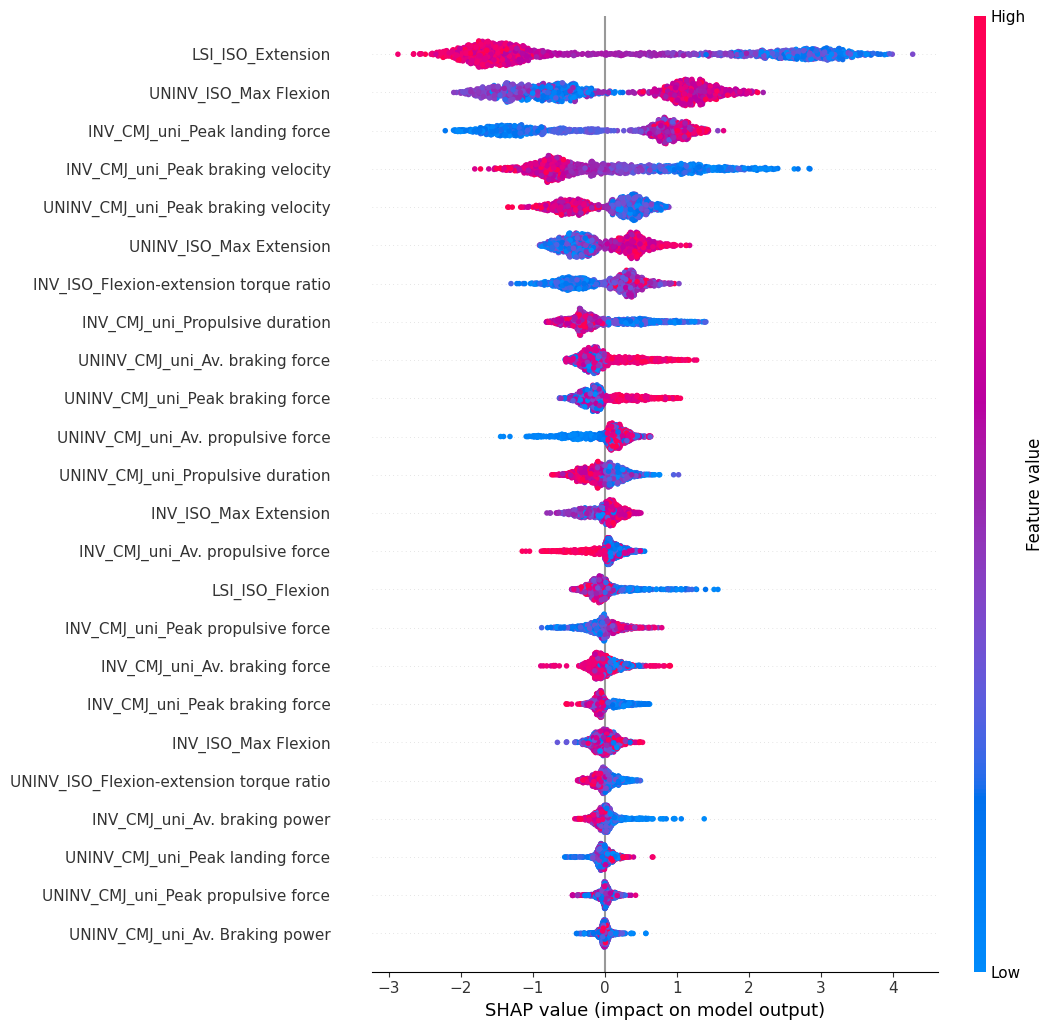

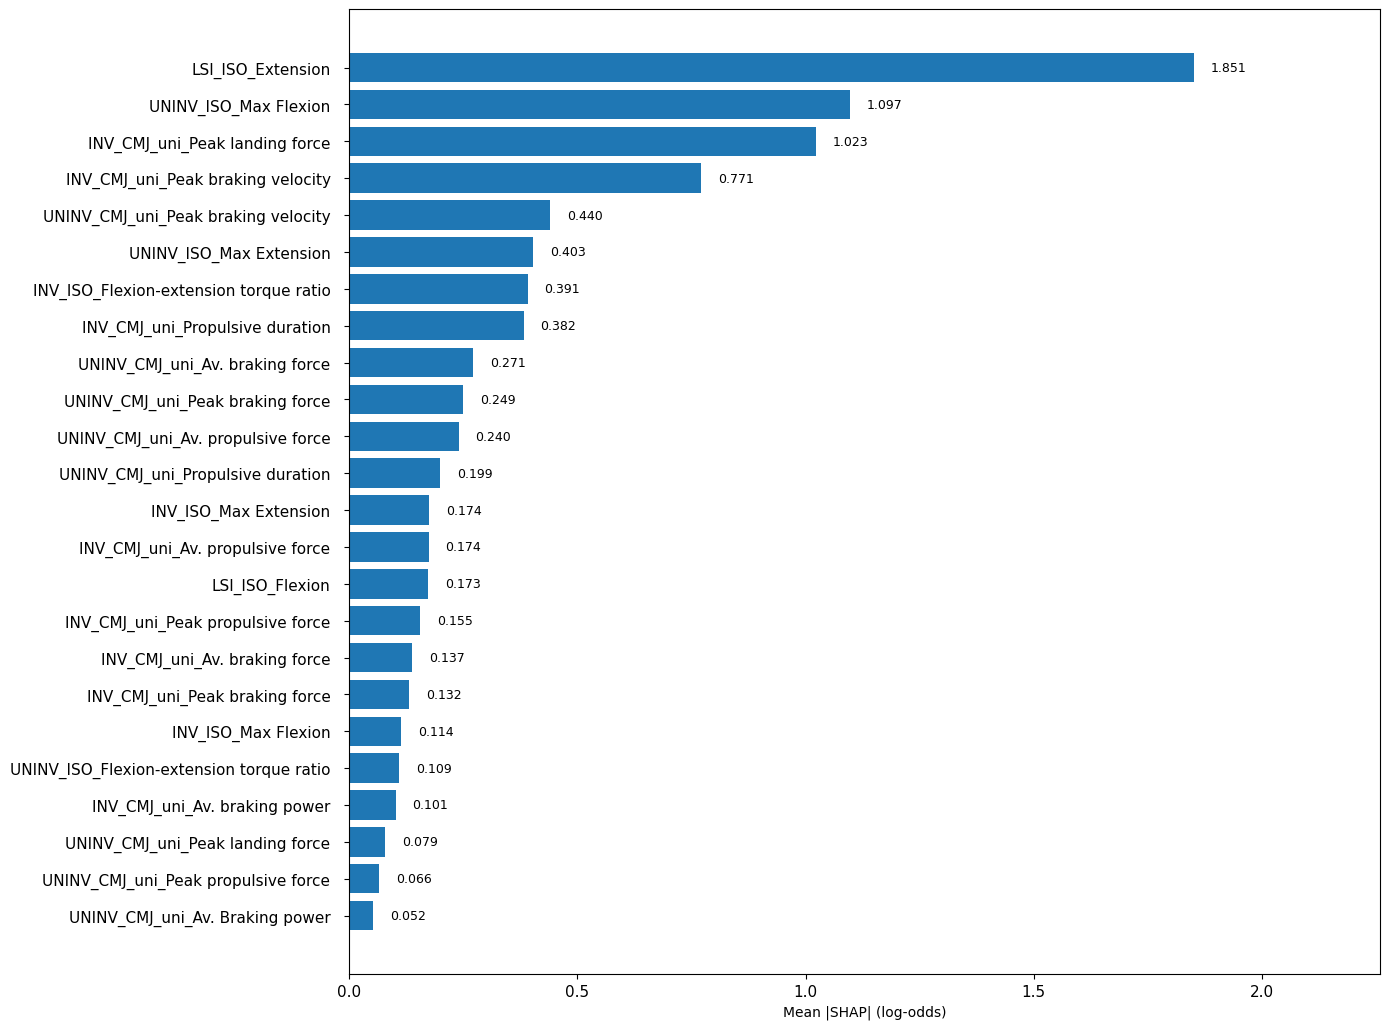

In [16]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "abs"   # "abs" oder "signed"
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|)
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)| für Sortierung

order_bar = np.argsort(ranking_scores)[::-1]               # absteigend                             
order_bee = order_bar                                      # Beeswarm: Top oben

# Einheitliche Höhe pro Feature
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels in identischer Reihenfolge
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),
    sort=False,
    color_bar=True,
    plot_size=(w, h),
    show=False
)

ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # Breite bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))

y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: signed_mean (mit Vorzeichen), zentriert um 0
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Label am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.3f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.3f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (log-odds, signed)")

else:
    # Anzeige: mean(|SHAP|)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.3f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (log-odds)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()




Dieser Codeblock erstellt **zwei globale SHAP-Visualisierungen nur für die Top-K wichtigsten Features**:

- sortiert alle Features entweder nach **mean(|SHAP|)** oder **|mean(SHAP)|**,
- wählt daraus nur die **Top-K Features** aus,
- erzeugt einen **SHAP-Beeswarm-Plot** für diese Top-K Features,
- erstellt zusätzlich einen **Balkenplot** mit den entsprechenden globalen SHAP-Werten,
- zeigt dabei je nach Einstellung entweder
  - die **mittlere absolute SHAP-Wichtigkeit** oder
  - den **mittleren signierten SHAP-Effekt**,
- und formatiert beide Grafiken mit **umgebrochenen Labels und größerem Layout** für bessere Lesbarkeit.

Ziel ist eine **kompakte und fokussierte Darstellung der wichtigsten SHAP-Features**.

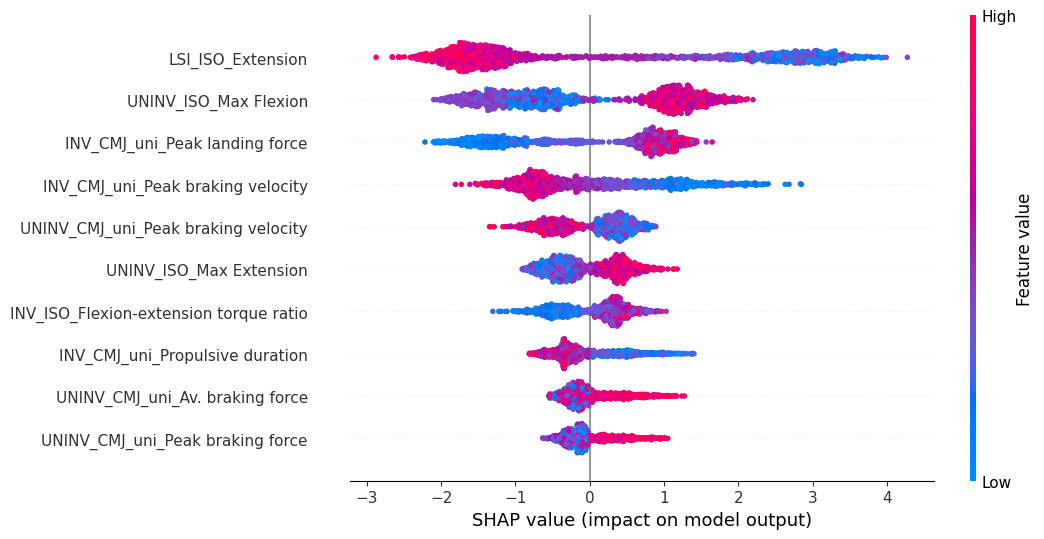

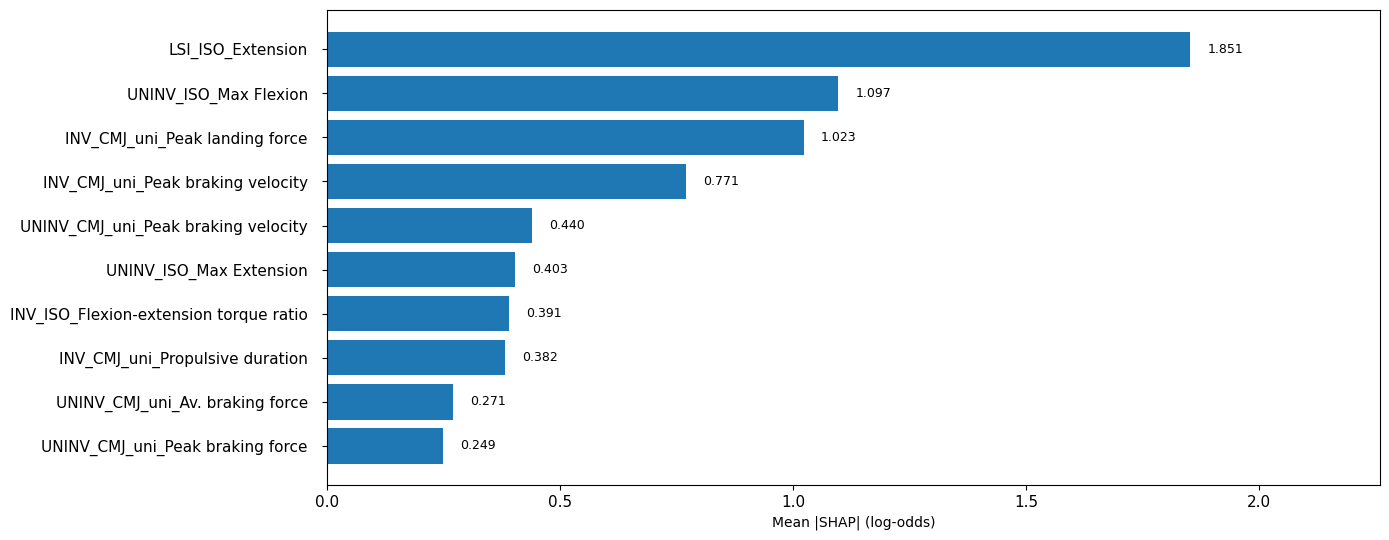

In [17]:
import numpy as np
import matplotlib.pyplot as plt
import textwrap
import shap

# -----------------------------
# Parameter: Ranking-Auswahl
# -----------------------------
rank_by = "abs"   # "abs" oder "signed"
TOP_K = 10 
wrap_width = 40
row_height = 0.35
w = 11.0

# -----------------------------
# Reihenfolge basierend auf rank_by
# -----------------------------
if rank_by not in ("abs", "signed"):
    raise ValueError("rank_by must be 'abs' or 'signed'.")

if rank_by == "abs":
    ranking_scores = abs_mean_shaps.copy()                 # mean(|SHAP|)
else:  # rank_by == "signed"
    ranking_scores = np.abs(signed_mean_shaps).copy()      # |mean(SHAP)| für Sortierung

order_bar_full = np.argsort(ranking_scores)[::-1]          # absteigend
top_k = min(TOP_K, len(order_bar_full))                    # falls <10 Features
order_bee = order_bar_full[:top_k]                         # << nur Top K
order_bar = order_bee                                      # identisch verwenden

# Höhe an Top K anpassen
h = row_height * len(order_bee) + 2.0

# Einheitliche, weich umgebrochene Labels (Top K)
wrapped_names = [textwrap.fill(features[i], width=wrap_width) for i in order_bee]

# =============================
# 1) BEESWARM
# =============================
shap.summary_plot(
    shap_stack[:, order_bee],
    features=X_stack[:, order_bee],
    feature_names=wrapped_names,
    plot_type="dot",
    max_display=len(order_bee),   # << sicherheitshalber
    sort=False,
    color_bar=True,
    plot_size=(w, h),
    show=False
)
ax = plt.gca()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
plt.gcf().subplots_adjust(left=0.35, right=0.96, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()

# =============================
# 2) BALKENPLOT (zweite Grafik)
# =============================

w2 = 14.0        # Breite bei Bedarf weiter erhöhen
pad_frac = 0.22  # zusätzlicher Platz rechts/links für Labels

fig, ax = plt.subplots(figsize=(w2, h))

y = np.arange(len(order_bee))

if rank_by == "signed":
    # Anzeige: signed_mean (mit Vorzeichen), zentriert um 0
    vals = signed_mean_shaps[order_bee]
    max_abs = np.nanmax(np.abs(vals)) if vals.size else 1.0
    ax.barh(y, vals)

    # Werte-Label am Balkenende
    eps = 0.02 * max_abs
    for yi, v in zip(y, vals):
        if np.isfinite(v) and v != 0:
            ax.text(v + (eps if v > 0 else -eps), yi, f"{v:+.3f}",
                    va='center', ha=('left' if v > 0 else 'right'), fontsize=9)
        else:
            ax.text(0 + eps, yi, f"{0:+.3f}", va='center', ha='left', fontsize=9)

    # symmetrische Achse mit Extra-Puffer
    ax.set_xlim(-max_abs * (1 + pad_frac), max_abs * (1 + pad_frac))
    ax.axvline(0, linewidth=0.8)
    ax.set_xlabel("Mean SHAP (log-odds, signed)")

else:
    # Anzeige: mean(|SHAP|)
    vals = abs_mean_shaps[order_bee]
    vmax = np.nanmax(vals) if vals.size else 1.0
    ax.barh(y, vals)

    eps = 0.02 * vmax
    for yi, v in zip(y, vals):
        v = 0.0 if not np.isfinite(v) else v
        ax.text(v + eps, yi, f"{v:.3f}", va='center', ha='left', fontsize=9)

    ax.set_xlim(0, vmax * (1 + pad_frac))
    ax.set_xlabel("Mean |SHAP| (log-odds)")

# Y-Achse und Layout wie im Beeswarm
ax.set_yticks(y)
ax.set_yticklabels(wrapped_names)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=11, pad=10)
ax.tick_params(axis='x', labelsize=11)
fig.subplots_adjust(left=0.35, right=0.985, top=0.96, bottom=0.06)
plt.tight_layout()
plt.show()




Dieser Codeblock berechnet **SHAP-Werte für eine logistische Regression** über eine **Repeated Stratified Cross-Validation** und speichert zusätzlich die **zugehörigen Fall-IDs** für jede SHAP-Zeile:

- lädt einen Datensatz mit binärer Zielvariable,
- verwendet optional eine **echte ID-Spalte** oder alternativ den **DataFrame-Index** als Fall-ID,
- führt eine **5×20 Repeated Stratified Cross-Validation** durch,
- skaliert die Features pro Fold mit **StandardScaler**,
- trainiert in jedem Fold eine **logistische Regression**,
- berechnet mit **SHAP LinearExplainer** die **Feature-Beiträge in Log-Odds** für die Testdaten,
- sammelt über alle Folds die **SHAP-Werte**, die **skalierten Testdaten** und die **zugehörigen IDs**,
- berechnet daraus den **mittleren signierten SHAP-Wert** und den **mittleren absoluten SHAP-Wert** pro Feature,
- und prüft die SHAP-Werte abschließend auf **NaN/Inf und Wertebereich**.

Ziel ist eine **globale SHAP-Analyse mit eindeutiger Zuordnung jeder SHAP-Zeile zu einer Person bzw. Beobachtung**.

In [18]:
import numpy as np
import pandas as pd
from sklearn.model_selection import RepeatedStratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
import shap

def collect_shap_data_lr(
    data_path,
    target_column="Verletzungsstatus",
    cv_splits=5,
    cv_repeats=2,
    shap_background_size=100,
    use_class_weight=False,
    max_iter=200,
    C=1.0,
    verbose=False,
    subject_id_column=None  # optional: echte ID-Spalte; None ⇒ df.index als ID
):
    """
    Trainiert LR mit CV, sammelt SHAP (log-odds) und gibt zurück:
      - features: Feature-Namen in Originalreihenfolge
      - shap_stack: gestackte SHAP-Matrix (alle Folds, alle Test-Samples)
      - X_stack:   gestackte (skalierte) Test-Features
      - exp_val:   expected_value (Skalar) für die positive Klasse (1)
      - last_model, last_test_len: wie zuvor
      - signed_mean_shaps: mean(SHAP) je Feature (Richtung)
      - abs_mean_shaps:    mean(|SHAP|) je Feature (Wichtigkeit)
      - subject_ids_stack: (N_ooF,) ID je Zeile (Index-Fallback, wenn keine ID-Spalte)
    """
    # 1) Daten einlesen
    df = pd.read_excel(data_path)
    if target_column not in df.columns:
        raise ValueError(f"target_column '{target_column}' not found in data.")
    y = df[target_column].astype(int)

    # ID-Quelle definieren (Index als Fallback)
    if subject_id_column is None:
        sid_values = df.index.to_numpy()
        drop_cols = [target_column]
    else:
        if subject_id_column not in df.columns:
            raise ValueError(f"subject_id_column '{subject_id_column}' not found in data.")
        sid_values = df[subject_id_column].to_numpy()
        drop_cols = [target_column, subject_id_column]

    # Feature-Matrix (ID & Target raus)
    X = df.drop(columns=drop_cols, errors="ignore")
    features = X.columns.tolist()
    if len(features) == 0:
        raise ValueError("No features left after dropping target/ID columns.")

    # 2) CV-Setup
    cv = RepeatedStratifiedKFold(n_splits=cv_splits, n_repeats=cv_repeats, random_state=42)
    all_shap, all_X, all_ids = [], [], []
    last_exp_val = None

    if verbose:
        print("→ Starte LR + SHAP (log-odds)…")

    rng_global = np.random.default_rng(42)

    for fold, (train_idx, test_idx) in enumerate(cv.split(X, y), start=1):
        if verbose: print(f"Fold {fold}")

        X_train, X_test = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_test = y.iloc[train_idx], y.iloc[test_idx]

        # 3) Skalierung (kein Leakage)
        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s  = scaler.transform(X_test)

        # 4) Logistische Regression
        lr = LogisticRegression(
            penalty="l2",
            solver="lbfgs",
            max_iter=max_iter,
            C=C,
            class_weight=("balanced" if use_class_weight else None),
            n_jobs=None
        )
        lr.fit(X_train_s, y_train)

        last_model    = lr
        last_test_len = X_test_s.shape[0]

        # 5) SHAP: LinearExplainer (log-odds), Background aus TRAIN
        n_bg = min(shap_background_size, len(X_train_s))
        bg_idx = rng_global.choice(len(X_train_s), size=n_bg, replace=False)
        bg = X_train_s[bg_idx, :]

        expl = shap.LinearExplainer(
            lr, bg,
            feature_names=features,
            model_output="log_odds"
        )
        sv = expl(X_test_s)

        vals = np.nan_to_num(sv.values, nan=0.0, posinf=0.0, neginf=0.0)
        all_shap.append(vals)
        all_X.append(X_test_s)

        # IDs der Testfälle (gleiche Reihenfolge wie SHAP) sammeln
        test_ids = sid_values[test_idx]
        all_ids.append(test_ids)

        # expected_value für Klasse 1
        exp_raw = expl.expected_value
        if isinstance(exp_raw, (list, tuple, np.ndarray)):
            pos_idx = int(np.where(lr.classes_ == 1)[0][0])
            last_exp_val = float(np.ravel(exp_raw)[pos_idx])
        else:
            last_exp_val = float(exp_raw)

    # 6) Stacking
    shap_stack = np.vstack(all_shap)       # [N_total, n_features]
    X_stack    = np.vstack(all_X)          # [N_total, n_features]
    subject_ids_stack = np.concatenate(all_ids)  # [N_total,]

    # 7) Kennzahlen (global)
    signed_mean_shaps = np.nanmean(shap_stack, axis=0)          # mean(SHAP)
    abs_mean_shaps    = np.nanmean(np.abs(shap_stack), axis=0)  # mean(|SHAP|)

    return (
        features,
        shap_stack,
        X_stack,
        last_exp_val,
        last_model,
        last_test_len,
        signed_mean_shaps,
        abs_mean_shaps,
        subject_ids_stack
    )

# ========= Aufruf =========
DATA_PATH = r"K:\Team\Böhmer_Michael\PAPER\Neuer_Ansatz\Finaler_Datensatz_ML\zweiter_Ansatz\Motum_ML.xlsx"
(features, shap_stack, X_stack, exp_val, last_model, last_test_len,
 signed_mean_shaps, abs_mean_shaps, subject_ids_stack) = collect_shap_data_lr(
    data_path            = DATA_PATH,
    target_column        = "Verletzungsstatus",
    cv_splits            = 5,
    cv_repeats           = 20,
    shap_background_size = 100,
    use_class_weight     = False,
    max_iter             = 200,
    C                    = 1.0,
    verbose              = False,
    subject_id_column    = None  # None ⇒ df.index als ID
)

print("\nSHAP-Wertprüfung:")
print("→ Min:", shap_stack.min(), "Max:", shap_stack.max(), "Mean:", shap_stack.mean())
print("→ Anzahl NaN:", np.isnan(shap_stack).sum(), "Inf:", np.isinf(shap_stack).sum())




SHAP-Wertprüfung:
→ Min: -4.601785791104535 Max: 4.450765755077146 Mean: -0.008208019231255208
→ Anzahl NaN: 0 Inf: 0


Dieser Code erstellt eine **SHAP-Feature-Tabelle mit statistischen Kennzahlen und 95 %-Konfidenzintervallen**:

- aggregiert zunächst die **SHAP-Werte pro Subjekt** (falls mehrere Beobachtungen pro Person existieren),
- berechnet pro Feature mehrere **Interpretationsmetriken**:
  - **mean|SHAP|** – globale Feature-Wichtigkeit  
  - **signed_mean** – durchschnittliche Richtung des Effekts  
  - **p_pos** – Anteil positiver SHAP-Beiträge  
  - **FI (Flip Index)** – Maß für Richtungswechsel der Effekte  
  - **RK (Richtungs-Kohärenz)** – Stabilität der Effekt-Richtung
- schätzt für alle Metriken **95 %-Konfidenzintervalle mittels Cluster-Bootstrap** auf Subjektebene,
- sortiert die Features nach **mean|SHAP|**,
- und erzeugt eine **formatierte Tabelle mit Werten und Konfidenzintervallen** für die Anzeige.

Ziel ist eine **statistisch abgesicherte globale Interpretation der wichtigsten Modellfeatures**.

In [17]:
import numpy as np
import pandas as pd

def _aggregate_subject_level(shap_stack, subject_ids):
    """
    Mittelt SHAPs je Subjekt (hier: Zeilenindex-Cluster) → (S × p) Matrix.
    subject_ids: (N_ooF,) gleiche Reihenfolge wie shap_stack.
    """
    df = pd.DataFrame(shap_stack)
    df["__sid__"] = subject_ids
    subj_means = df.groupby("__sid__", sort=False).mean()
    subj_ids = subj_means.index.to_numpy()
    subj_means = subj_means.drop(columns=[], errors="ignore")  # no-op
    return subj_means.values, subj_ids  # (S × p), (S,)

def _feature_metrics(subject_level_phi):
    """
    subject_level_phi: (S × p) SHAP-Matrix nach Subjekt-Mittelung.
    Liefert je Feature:
      - abs_mean = mean(|phi|)
      - signed_mean = mean(phi)
      - p_pos = Anteil(phi>0)
      - FI = 2*min(p_pos, 1-p_pos)
      - RK = |mean(phi)| / mean(|phi|)
    """
    S, p = subject_level_phi.shape
    abs_mean     = np.nanmean(np.abs(subject_level_phi), axis=0)
    signed_mean  = np.nanmean(subject_level_phi, axis=0)
    p_pos        = np.nanmean((subject_level_phi > 0).astype(float), axis=0)
    fi           = 2.0 * np.minimum(p_pos, 1.0 - p_pos)
    eps          = 1e-12
    rk           = np.abs(signed_mean) / np.maximum(abs_mean, eps)
    return abs_mean, signed_mean, p_pos, fi, rk

def shap_table_with_boot_ci(
    shap_stack, subject_ids_stack, features,
    B=2000, alpha=0.05, random_state=42
):
    """
    Baut eine Tabelle pro Feature mit Punktwerten + 95%-KI:
      - mean(|SHAP|), signed mean, p_pos, FI, RK
    Sortiert nach mean(|SHAP|) absteigend.
    Bootstrap: Cluster-Bootstrap über Subjekte (resample IDs).
    """
    if subject_ids_stack is None:
        raise ValueError("subject_ids_stack ist None. Bitte collect_shap_data_lr mit Index/ID nutzen.")

    rng = np.random.default_rng(random_state)

    # 1) Subjekt-Ebene aggregieren
    subj_phi, subj_ids = _aggregate_subject_level(shap_stack, subject_ids_stack)  # (S × p)

    # 2) Punkt-Schätzer
    abs_mean_pt, signed_mean_pt, p_pos_pt, fi_pt, rk_pt = _feature_metrics(subj_phi)

    # 3) Bootstrap (Cluster über Subjekte)
    S, p = subj_phi.shape
    B = int(B)
    abs_mean_bs = np.empty((B, p))
    signed_bs   = np.empty((B, p))
    ppos_bs     = np.empty((B, p))
    fi_bs       = np.empty((B, p))
    rk_bs       = np.empty((B, p))

    for b in range(B):
        boot_idx = rng.integers(0, S, size=S)   # resample Subjekte
        boot_phi = subj_phi[boot_idx, :]
        am, sm, pp, fi, rk = _feature_metrics(boot_phi)
        abs_mean_bs[b, :], signed_bs[b, :], ppos_bs[b, :], fi_bs[b, :], rk_bs[b, :] = am, sm, pp, fi, rk

    lo, hi = 100*alpha/2, 100*(1-alpha/2)
    def ci(arr):  # arr: (B × p)
        return (np.nanpercentile(arr, lo, axis=0),
                np.nanpercentile(arr, hi, axis=0))

    abs_lo, abs_hi = ci(abs_mean_bs)
    sm_lo,  sm_hi  = ci(signed_bs)
    pp_lo,  pp_hi  = ci(ppos_bs)
    fi_lo,  fi_hi  = ci(fi_bs)
    rk_lo,  rk_hi  = ci(rk_bs)

    # 4) Numerische Tabelle bauen & sortieren (Rohwerte + KI-Rohspalten)
    df_out = pd.DataFrame({
        "Feature": features,
        "mean|SHAP|": abs_mean_pt,
        "mean|SHAP|_lo": abs_lo,
        "mean|SHAP|_hi": abs_hi,
        "signed_mean": signed_mean_pt,
        "signed_lo": sm_lo,
        "signed_hi": sm_hi,
        "p_pos": p_pos_pt,
        "p_pos_lo": pp_lo,
        "p_pos_hi": pp_hi,
        "FI": fi_pt,
        "FI_lo": fi_lo,
        "FI_hi": fi_hi,
        "RK": rk_pt,
        "RK_lo": rk_lo,
        "RK_hi": rk_hi,
    }).sort_values("mean|SHAP|", ascending=False).reset_index(drop=True)

    return df_out

# ------------------ Anzeige/Formatting: KI direkt neben Wert ------------------

def _fmt_ci(lo, hi, decimals=3, as_percent=False):
    if as_percent:
        if np.isnan(lo) or np.isnan(hi):
            return "(NA–NA)"
        return f"({lo*100:.{decimals}f}–{hi*100:.{decimals}f} %)"
    else:
        if np.isnan(lo) or np.isnan(hi):
            return "(NA–NA)"
        return f"({lo:.{decimals}f}–{hi:.{decimals}f})"

def format_shap_table_for_display(
    df_numeric: pd.DataFrame,
    decimals_main=3,
    as_percent_for=("p_pos", "FI"),  # diese Metriken optional als % zeigen
):
    """
    Nimmt die numerische df (mit *_lo/_hi) und erzeugt eine Display-Tabelle,
    in der jede Metrik direkt eine KI-Spalte daneben hat.
    """
    # Kopie, damit Original erhalten bleibt
    dfn = df_numeric.copy()

    # Optional: numerische Wertespalten runden für die Anzeige
    def _round_series(s, as_percent=False):
        if as_percent:
            return (s * 100).round(decimals_main)
        return s.round(decimals_main)

    # Metriken-Definitionen (Name, lo, hi, als Prozent?)
    specs = [
        ("mean|SHAP|",  "mean|SHAP|_lo", "mean|SHAP|_hi", False),
        ("signed_mean", "signed_lo",     "signed_hi",     False),
        ("p_pos",       "p_pos_lo",      "p_pos_hi",      "p_pos" in as_percent_for),
        ("FI",          "FI_lo",         "FI_hi",         "FI" in as_percent_for),
        ("RK",          "RK_lo",         "RK_hi",         False),
    ]

    # Display-Spalten bauen
    disp_cols = ["Feature"]
    disp_data = {"Feature": dfn["Feature"]}

    for name, lo_name, hi_name, as_pct in specs:
        # Wert
        val_col = name
        val_series = _round_series(dfn[val_col], as_percent=as_pct)
        # KI
        ci_col = f"{name} KI"
        ci_series = [
            _fmt_ci(dfn[lo_name].iloc[i], dfn[hi_name].iloc[i],
                    decimals=decimals_main, as_percent=as_pct)
            for i in range(len(dfn))
        ]
        disp_data[val_col] = val_series
        disp_data[ci_col] = ci_series
        disp_cols.extend([val_col, ci_col])

    df_display = pd.DataFrame(disp_data, columns=disp_cols)

    return df_display

# ========= Ausführen: Tabelle berechnen & schön anzeigen =========
df_shap_numeric = shap_table_with_boot_ci(
    shap_stack=shap_stack,
    subject_ids_stack=subject_ids_stack,  # aus Zelle 1
    features=features,
    B=2000,           # für schnelle Tests ggf. 500
    alpha=0.05,
    random_state=42
)

df_shap_display = format_shap_table_for_display(
    df_shap_numeric,
    decimals_main=3,
    as_percent_for=("p_pos", "FI")  # p_pos & FI als Prozente; entferne, wenn du Dezimal willst
)

# Anzeige (Jupyter) oder Fallback auf print
try:
    display(df_shap_display)
except NameError:
    print(df_shap_display.to_string(index=False))

# ------- Legende unter der Tabelle ausgeben (ohne KI-Spalten erklären) -------
legend = """
Erklärung der Metriken (SHAP in Log-Odds):

- mean|SHAP|: mittlere absolute SHAP-Werte (globale Wichtigkeit, richtungsunabhängig).
- signed_mean: mittlerer gerichteter SHAP (kann sich bei gemischten Vorzeichen wegmitteln).
- p_pos: Anteil der (subjekt-aggregierten) Fälle mit SHAP > 0 (Richtung Klasse 1); hier als Prozent ausgegeben.
- FI: Flip-Index = 2*min(p_pos, 1-p_pos); 0 ≈ kaum Flippen, 1 ≈ starkes Flippen (hier als Prozent).
- RK: Richtungs-Kohärenz = |signed_mean| / mean|SHAP| ∈ [0,1]; nahe 1 = Richtung konsistent, nahe 0 = heterogen.

Hinweis: KIs sind 95%-Konfidenzintervalle via Cluster-Bootstrap (Resampling auf Subjektebene).
"""
print(legend)


,Feature,mean|SHAP|,mean|SHAP| KI,signed_mean,signed_mean KI,p_pos,p_pos KI,FI,FI KI,RK,RK KI
0,INV_CMJ_uni_Av. propulsive force,0.923,(0.756–1.113),-0.006,(-0.270–0.268),48.000,(37.333–58.667 %),96.000,(74.667–98.667 %),0.006,(0.005–0.332)
1,UNINV_CMJ_uni_Peak braking force,0.832,(0.681–1.001),0.022,(-0.217–0.280),44.000,(33.300–56.000 %),88.000,(66.600–98.667 %),0.026,(0.005–0.332)
2,INV_CMJ_uni_Relative Peak Landing Force-Mittel...,0.828,(0.669–1.006),-0.007,(-0.257–0.258),42.667,(32.000–54.667 %),85.333,(64.000–98.667 %),0.008,(0.005–0.354)
3,CMJ_Braking duration,0.545,(0.445–0.660),0.006,(-0.153–0.182),46.667,(34.667–58.667 %),93.333,(69.333–98.667 %),0.012,(0.006–0.341)
4,UNINV_CMJ_uni_Peak Propulsive Force-Mittelwert...,0.533,(0.437–0.640),0.007,(-0.151–0.158),50.667,(38.667–61.333 %),98.667,(74.667–98.667 %),0.013,(0.005–0.337)
5,INV_CMJ_uni_Peak Braking Velocity-Mittelwert [...,0.521,(0.440–0.610),0.000,(-0.141–0.150),42.667,(32.000–54.667 %),85.333,(64.000–98.667 %),0.001,(0.004–0.323)
6,LSI_ISO_Extension,0.512,(0.420–0.604),-0.002,(-0.149–0.140),48.000,(37.333–58.667 %),96.000,(72.000–98.667 %),0.003,(0.005–0.325)
7,INV_ISO_Drehmoment_Verhaeltnis Flexion Extension,0.495,(0.404–0.595),-0.008,(-0.152–0.145),52.000,(41.333–64.000 %),96.000,(72.000–98.667 %),0.017,(0.005–0.341)
8,INV_CMJ_uni_Bremsimpuls-Mittelwert [N*s],0.446,(0.375–0.523),0.001,(-0.121–0.130),44.000,(33.333–56.000 %),88.000,(66.667–98.667 %),0.003,(0.005–0.325)
9,UNINV_ISO_Max Extension,0.421,(0.344–0.509),-0.003,(-0.129–0.113),52.000,(41.333–62.667 %),96.000,(72.000–98.667 %),0.007,(0.004–0.327)



Erklärung der Metriken (SHAP in Log-Odds):

- mean|SHAP|: mittlere absolute SHAP-Werte (globale Wichtigkeit, richtungsunabhängig).
- signed_mean: mittlerer gerichteter SHAP (kann sich bei gemischten Vorzeichen wegmitteln).
- p_pos: Anteil der (subjekt-aggregierten) Fälle mit SHAP > 0 (Richtung Klasse 1); hier als Prozent ausgegeben.
- FI: Flip-Index = 2*min(p_pos, 1-p_pos); 0 ≈ kaum Flippen, 1 ≈ starkes Flippen (hier als Prozent).
- RK: Richtungs-Kohärenz = |signed_mean| / mean|SHAP| ∈ [0,1]; nahe 1 = Richtung konsistent, nahe 0 = heterogen.

Hinweis: KIs sind 95%-Konfidenzintervalle via Cluster-Bootstrap (Resampling auf Subjektebene).



Dieser Codeblock erstellt einen **lokalen SHAP-Waterfall-Plot für ein einzelnes Sample** und kombiniert ihn mit einem **erklärenden Header** zu einer gemeinsamen Grafik:

- wählt ein einzelnes Sample aus den SHAP-Daten aus,
- fasst optional **Null-Beiträge** zu einem Sammelblock zusammen,
- berechnet aus **Baseline + Summe der SHAP-Werte** die individuelle **Vorhersagewahrscheinlichkeit**,
- erstellt einen **Header** mit kurzer Interpretation der Richtung  
  (**rot = Richtung verletzt**, **blau = Richtung unverletzt**),
- erzeugt darunter den eigentlichen **SHAP-Waterfall-Plot**,
- speichert beide Teile temporär als Bilder,
- setzt sie zu **einer einzigen kombinierten Abbildung** zusammen,
- und zeigt diese direkt an.

Ziel ist eine **saubere, anschauliche lokale SHAP-Erklärung** für eine einzelne Beobachtung.

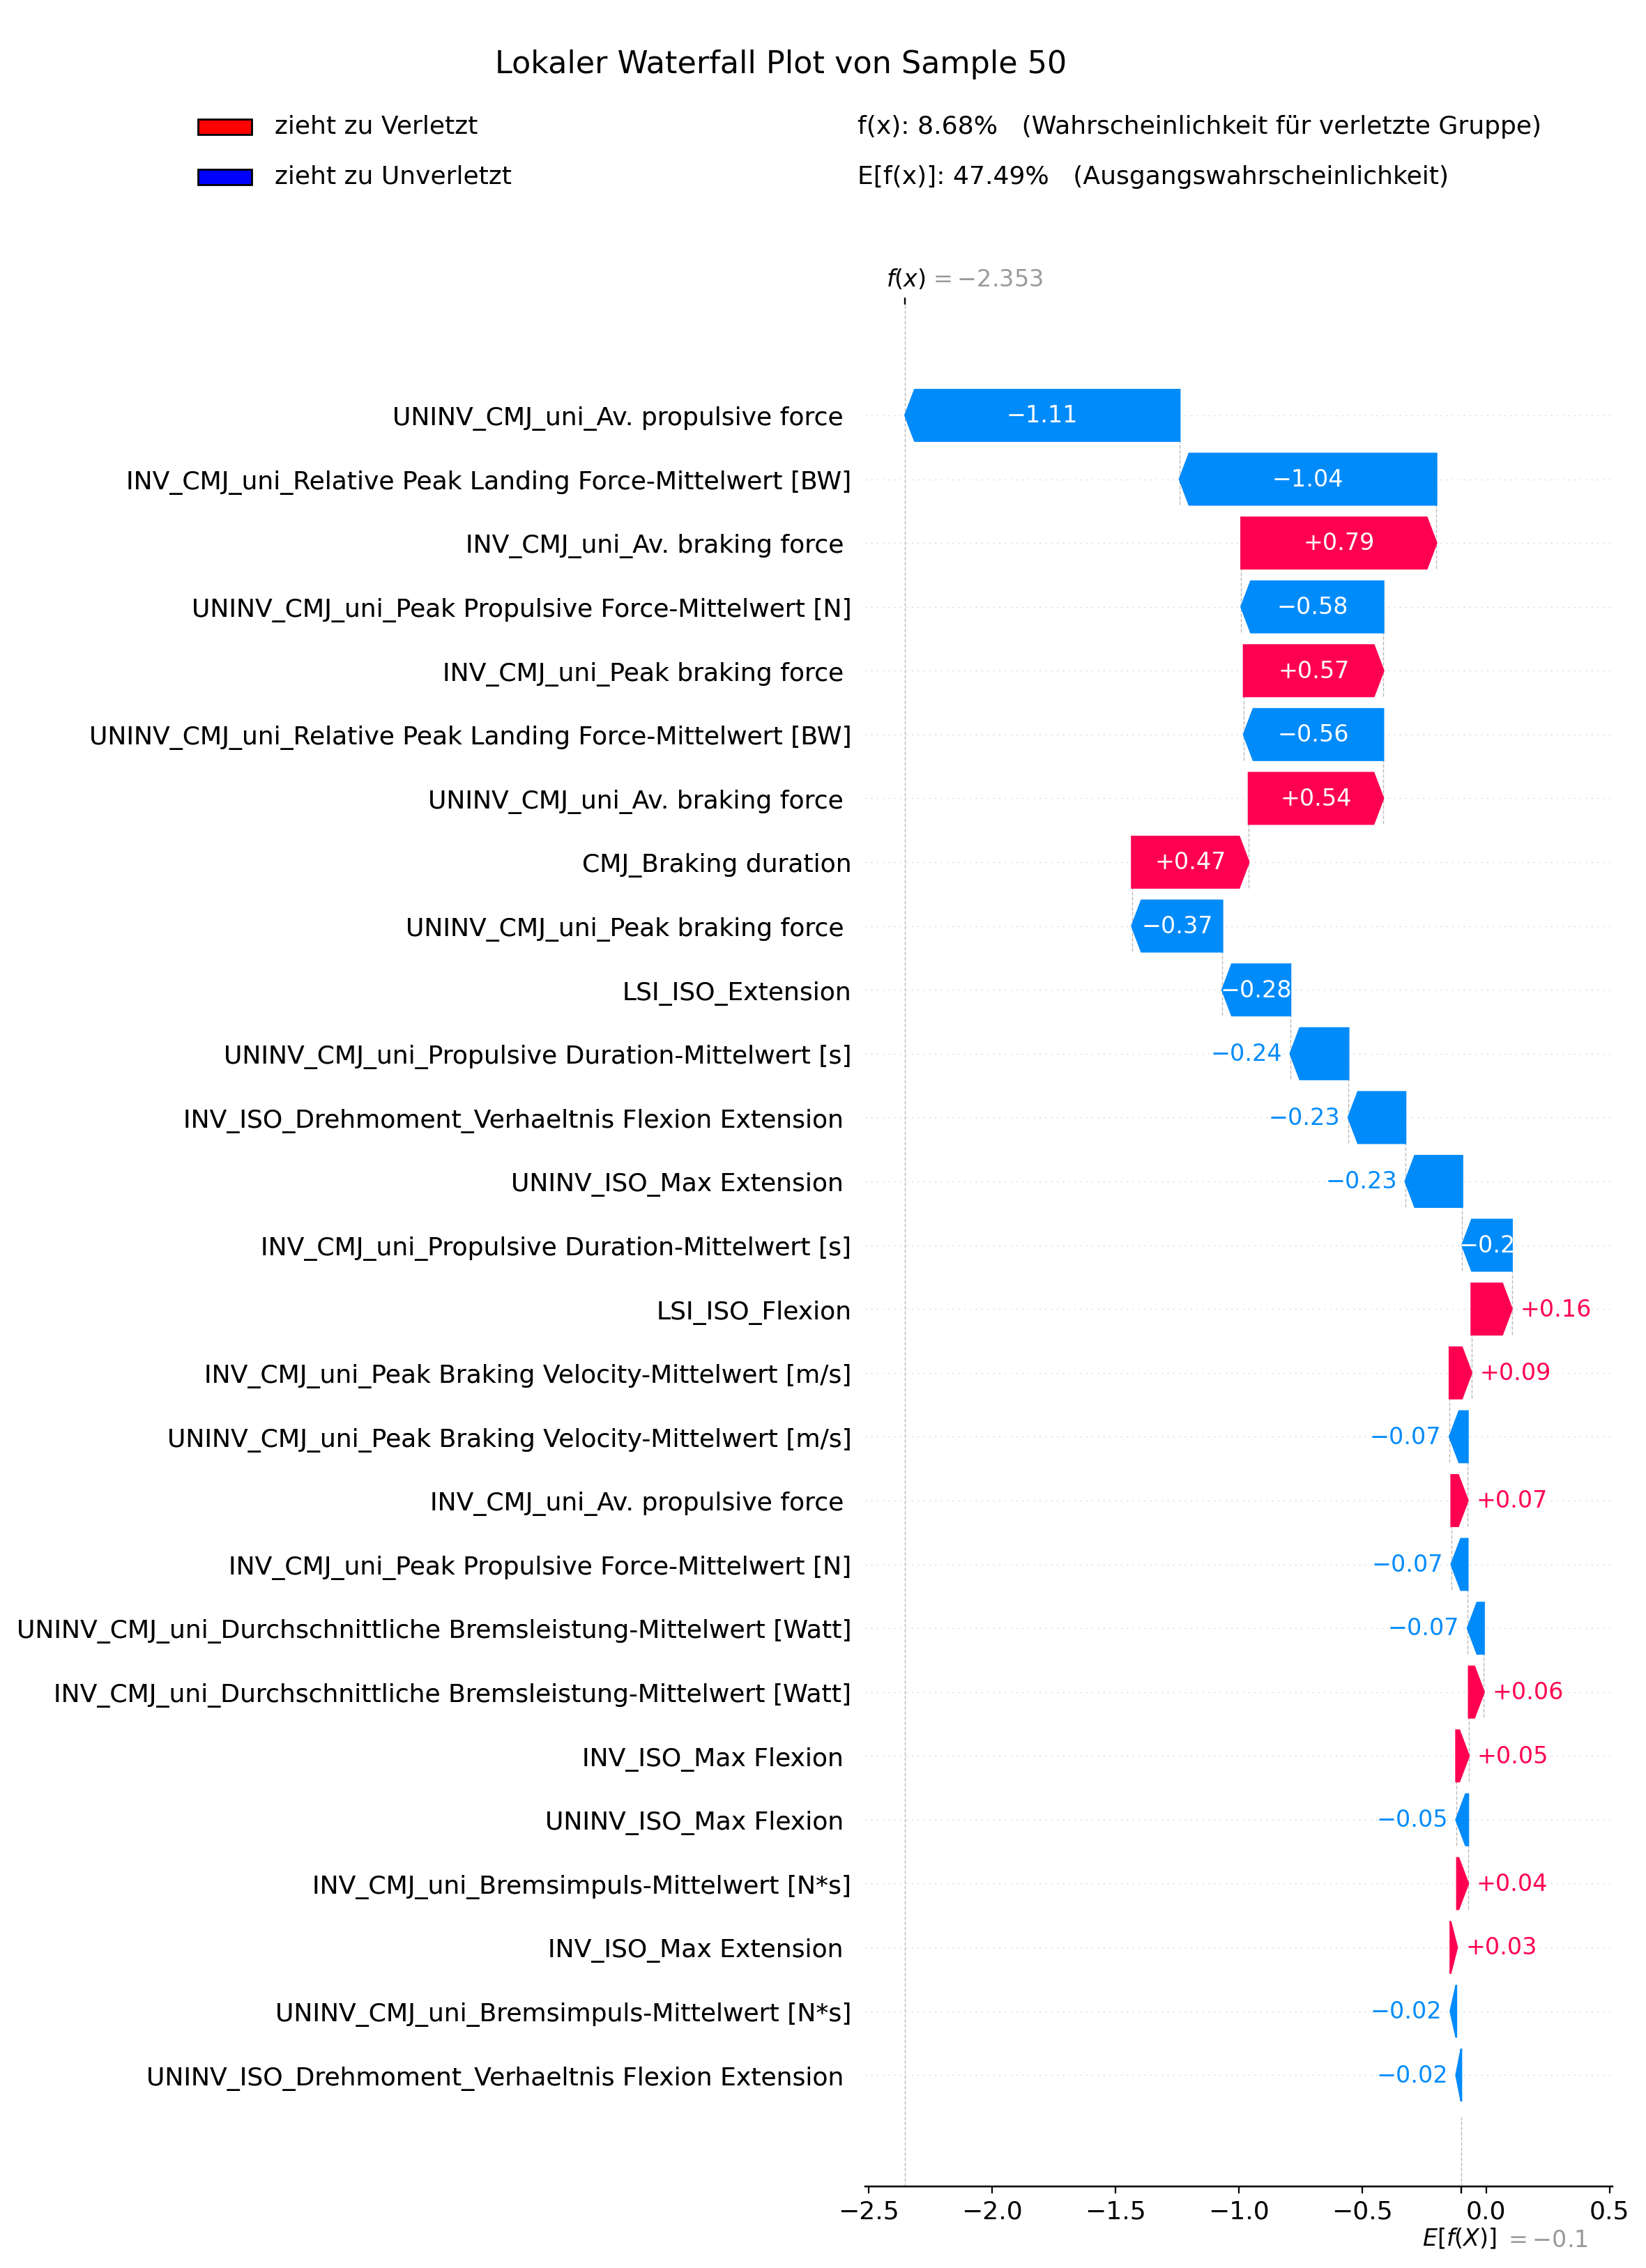

In [43]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from scipy.special import expit
from io import BytesIO
import tempfile, os
from PIL import Image
import shap

def plot_local_waterfall_combined_tempfiles(
    features,
    shap_stack,
    exp_val,
    sample_idx=None,
    combine_zeros=True,
    max_display=None,
    # Geometrie wie bei dir
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200,
    spacer_px=10
):
    # ----- Sample & Explanation vorbereiten (wie bei dir) -----
    if sample_idx is None:
        rng = np.random.default_rng(42)
        sample_idx = int(rng.integers(0, shap_stack.shape[0]))

    vals_full  = shap_stack[sample_idx, :]
    names_full = list(features)
    if combine_zeros:
        nz = vals_full != 0
        vals  = vals_full[nz].tolist()
        names = [names_full[i] for i in range(len(names_full)) if nz[i]]
        if (~nz).sum() > 0:
            names.append("Restliche Null-Features"); vals.append(0.0)
    else:
        vals, names = vals_full.tolist(), names_full

    exp = shap.Explanation(values=np.array(vals), base_values=float(exp_val), feature_names=names)

    fx_logit = exp.base_values + float(np.sum(exp.values))
    p_fx   = float(expit(fx_logit))
    p_base = float(expit(exp.base_values))

    # ===== 1) Header-Plot -> temporäre PNG (ohne tight) =====
    figA = plt.figure(figsize=(width, header_height), dpi=dpi)
    axA = figA.add_axes([0, 0, 1, 1]); axA.axis("off")

    axA.text(0.5, 0.80, f"Lokaler Waterfall Plot von Sample {sample_idx}",
             ha="center", va="center", fontsize=16)

    x_left_patch, x_left_text, x_right_col = 0.12, 0.17, 0.55
    y1, y2 = 0.55, 0.35
    box_w, box_h = 0.035, 0.06

    axA.add_patch(Rectangle((x_left_patch, y1 - box_h/2), box_w, box_h,
                            facecolor="red", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y1, "zieht zu Verletzt",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)
    axA.text(x_right_col, y1,
             f"f(x): {p_fx:,.2%}   (Wahrscheinlichkeit für verletzte Gruppe)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    axA.add_patch(Rectangle((x_left_patch, y2 - box_h/2), box_w, box_h,
                            facecolor="blue", edgecolor="black", transform=axA.transAxes))
    axA.text(x_left_text, y2, "zieht zu Unverletzt",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)
    axA.text(x_right_col, y2,
             f"E[f(x)]: {p_base:,.2%}   (Ausgangswahrscheinlichkeit)",
             ha="left", va="center", fontsize=13, transform=axA.transAxes)

    tmpA = tempfile.NamedTemporaryFile(delete=False, suffix=".png"); tmpA.close()
    figA.savefig(tmpA.name, format="png", dpi=dpi, facecolor=figA.get_facecolor(),
                 bbox_inches=None, pad_inches=0)  # << keine 'tight'-Beschneidung
    plt.close(figA)

    # ===== 2) Waterfall-Plot -> temporäre PNG (ohne tight) =====
    n_rows = len(exp.values) if max_display is None else min(max_display, len(exp.values))
    heightB = base_height + row_height * n_rows

    figB = plt.figure(figsize=(width, heightB), dpi=dpi)
    shap.plots.waterfall(exp, show=False,
                         max_display=(len(exp.values) if max_display is None else max_display))
    # deine manuelle Randsetzung (damit nichts abgeschnitten wird)
    plt.gcf().subplots_adjust(left=left, right=right, top=top, bottom=bottom)

    tmpB = tempfile.NamedTemporaryFile(delete=False, suffix=".png"); tmpB.close()
    figB = plt.gcf()
    figB.canvas.draw()  # sicherstellen, dass Layout fertig ist
    figB.savefig(tmpB.name, format="png", dpi=dpi, facecolor=figB.get_facecolor(),
                bbox_inches="tight", pad_inches=0.02)  # << nimmt die vollen Label-Extents mit

    plt.close(plt.gcf())

    # ===== 3) Beide PNGs laden & exakt untereinander packen =====
    imgA = Image.open(tmpA.name).convert("RGBA")
    imgB = Image.open(tmpB.name).convert("RGBA")

    # optionaler weißer Spacer
    if spacer_px > 0:
        spacer = Image.new("RGBA", (max(imgA.width, imgB.width), spacer_px), (255, 255, 255, 255))
    else:
        spacer = None

    # gleiche Breite herstellen durch **weißes Padding** (keine Skalierung!)
    W = max(imgA.width, imgB.width)
    if imgA.width != W:
        pad = Image.new("RGBA", (W - imgA.width, imgA.height), (255, 255, 255, 255))
        imgA = Image.fromarray(np.hstack([np.array(imgA), np.array(pad)]))
    if imgB.width != W:
        pad = Image.new("RGBA", (W - imgB.width, imgB.height), (255, 255, 255, 255))
        imgB = Image.fromarray(np.hstack([np.array(imgB), np.array(pad)]))

    parts = [imgA]
    if spacer is not None: parts.append(spacer)
    parts.append(imgB)

    total_h = sum(p.height for p in parts)
    combo = Image.new("RGBA", (W, total_h), (255, 255, 255, 255))
    y = 0
    for p in parts:
        combo.paste(p, (0, y))
        y += p.height

    # ===== 4) Nur EIN Bild anzeigen (1:1 Pixel, kein Zoom) =====
    combo_np = np.asarray(combo)[..., :3]  # RGB
    h_px, w_px = combo_np.shape[:2]
    fig = plt.figure(figsize=(w_px / dpi, h_px / dpi), dpi=dpi)
    ax = fig.add_axes([0, 0, 1, 1]); ax.axis("off")
    ax.imshow(combo_np, interpolation="none")
    plt.show()

    # Temp-Dateien aufräumen
    try:
        os.remove(tmpA.name); os.remove(tmpB.name)
    except Exception:
        pass

plot_local_waterfall_combined_tempfiles(
    features=features,
    shap_stack=shap_stack,
    exp_val=exp_val,
    sample_idx=50,          # oder None
    combine_zeros=True,
    max_display=None,
    width=11.0, header_height=1.8, row_height=0.18, base_height=1.2,
    left=0.30, right=0.97, top=0.98, bottom=0.08,
    dpi=200, spacer_px=0
)
